In [ ]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score,
    classification_report, confusion_matrix,
    silhouette_score
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Step 2: Load Dataset

df = pd.read_csv("online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# Dataset shape
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset info
df.info()

Rows and Columns: (12330, 18)

Columns:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates  

In [ ]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [ ]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
# Purchase status count
df['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


In [ ]:
# Purchase status percentage
df['Revenue'].value_counts(normalize=True) * 100

,proportion
Revenue,
False,84.525547
True,15.474453


In [ ]:
df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [ ]:
# Convert Revenue into Purchase_Status

df['Purchase_Status'] = df['Revenue'].astype(int)

df[['Revenue','Purchase_Status']].head()

,Revenue,Purchase_Status
0,False,0
1,False,0
2,False,0
3,False,0
4,False,0


In [ ]:
df['Browsing_Time'] = df['ProductRelated_Duration']

In [ ]:
np.random.seed(42)

df['Previous_Purchases'] = np.where(
    df['VisitorType'] == 'Returning_Visitor',
    np.random.randint(5, 25, len(df)),
    np.random.randint(0, 5, len(df))
)

In [ ]:
df['Discount_Applied'] = np.where(df['SpecialDay'] > 0, 1, 0)

In [ ]:
df['Total_Spending'] = df['PageValues'] * np.random.uniform(20, 80, len(df))

In [ ]:
df['Price'] = np.random.randint(20, 1000, len(df))

In [ ]:
df['Age'] = np.random.randint(18, 60, len(df))

In [ ]:
df['Gender'] = np.random.choice(
    ['Male', 'Female'],
    size=len(df)
)

In [ ]:
df['User_ID'] = np.arange(1, len(df)+1)

In [ ]:
df['Location'] = df['Region']

In [ ]:
df['Product_Category'] = np.where(
    df['ProductRelated'] < 20,
    'Electronics',
    np.where(
        df['ProductRelated'] < 40,
        'Fashion',
        np.where(
            df['ProductRelated'] < 70,
            'Home',
            'Sports'
        )
    )
)

In [ ]:
df['Rating'] = (
    2
    + (df['PageValues'] / df['PageValues'].max()) * 2
    + df['Purchase_Status'] * 0.8
    + df['Discount_Applied'] * 0.2
)

df['Rating'] = df['Rating'].clip(1,5).round(1)

In [ ]:
df[[
    'User_ID',
    'Price',
    'Browsing_Time',
    'Previous_Purchases',
    'Discount_Applied',
    'Total_Spending',
    'Age',
    'Gender',
    'Location',
    'Product_Category',
    'Rating',
    'Purchase_Status'
]].head()

,User_ID,Price,Browsing_Time,Previous_Purchases,Discount_Applied,Total_Spending,Age,Gender,Location,Product_Category,Rating,Purchase_Status
0,1,729,0.000000,11,0,0.0,34,Male,1,Electronics,2.0,0
1,2,576,64.000000,24,0,0.0,43,Male,1,Electronics,2.0,0
2,3,578,0.000000,19,0,0.0,35,Male,9,Electronics,2.0,0
3,4,983,2.666667,15,0,0.0,39,Male,2,Electronics,2.0,0
4,5,753,627.500000,12,0,0.0,23,Female,1,Electronics,2.0,0


In [ ]:
df[[
    'User_ID',
    'Price',
    'Browsing_Time',
    'Previous_Purchases',
    'Discount_Applied',
    'Total_Spending',
    'Age',
    'Gender',
    'Location',
    'Product_Category',
    'Rating',
    'Purchase_Status'
]].head()

,User_ID,Price,Browsing_Time,Previous_Purchases,Discount_Applied,Total_Spending,Age,Gender,Location,Product_Category,Rating,Purchase_Status
0,1,729,0.000000,11,0,0.0,34,Male,1,Electronics,2.0,0
1,2,576,64.000000,24,0,0.0,43,Male,1,Electronics,2.0,0
2,3,578,0.000000,19,0,0.0,35,Male,9,Electronics,2.0,0
3,4,983,2.666667,15,0,0.0,39,Male,2,Electronics,2.0,0
4,5,753,627.500000,12,0,0.0,23,Female,1,Electronics,2.0,0


Purchase Status Distribution

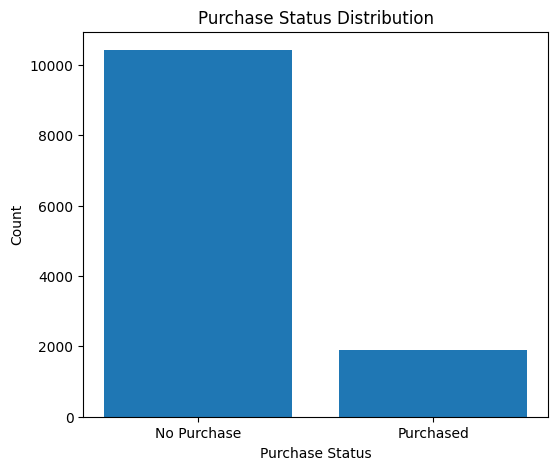

In [ ]:
purchase = df['Purchase_Status'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(['No Purchase','Purchased'], purchase.values)
plt.title("Purchase Status Distribution")
plt.xlabel("Purchase Status")
plt.ylabel("Count")
plt.savefig("Ecommerce_Recommendation_System/screenshots/01_purchase_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import numpy as np

np.random.seed(42)

df["Browsing_Time"] = df["ProductRelated_Duration"]
df["Purchase_Status"] = df["Revenue"].astype(int)

df["Previous_Purchases"] = np.where(
    df["VisitorType"] == "Returning_Visitor",
    np.random.randint(5, 25, len(df)),
    np.random.randint(0, 5, len(df))
)

df["Discount_Applied"] = np.where(df["SpecialDay"] > 0, 1, 0)
df["Total_Spending"] = df["PageValues"] * np.random.uniform(20, 80, len(df))
df["Price"] = np.random.randint(20, 1000, len(df))
df["Age"] = np.random.randint(18, 60, len(df))
df["Gender"] = np.random.choice(["Male", "Female"], size=len(df))
df["User_ID"] = np.arange(1, len(df) + 1)
df["Location"] = df["Region"]

df["Product_Category"] = np.where(
    df["ProductRelated"] < 20,
    "Electronics",
    np.where(
        df["ProductRelated"] < 40,
        "Fashion",
        np.where(df["ProductRelated"] < 70, "Home", "Sports")
    )
)

df["Rating"] = (
    2
    + (df["PageValues"] / df["PageValues"].max()) * 2
    + df["Purchase_Status"] * 0.8
    + df["Discount_Applied"] * 0.2
)

df["Rating"] = df["Rating"].clip(1, 5).round(1)

print("Feature engineering completed ✅")
print(df.columns.tolist())

Feature engineering completed ✅
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue', 'Purchase_Status', 'Browsing_Time', 'Previous_Purchases', 'Discount_Applied', 'Total_Spending', 'Price', 'Age', 'Gender', 'User_ID', 'Location', 'Product_Category', 'Rating']


Rating Distribution

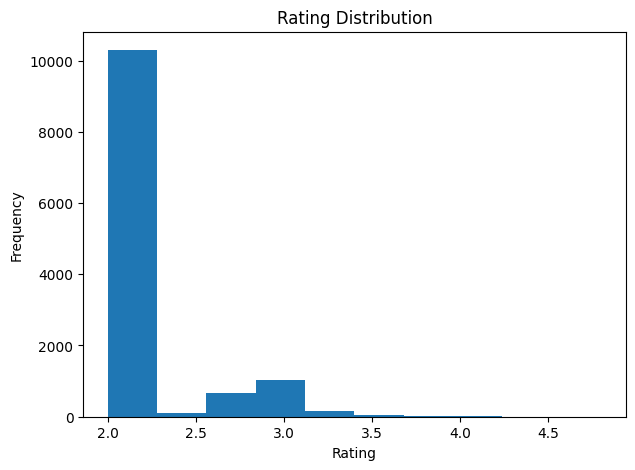

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("Ecommerce_Recommendation_System/screenshots", exist_ok=True)

plt.figure(figsize=(7,5))
plt.hist(df["Rating"], bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.savefig("Ecommerce_Recommendation_System/screenshots/02_rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Customer Age Distribution

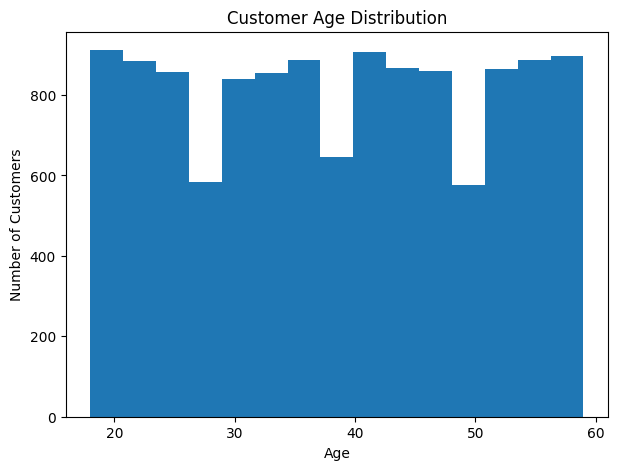

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(df['Age'], bins=15)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.savefig("Ecommerce_Recommendation_System/screenshots/03_Customer Age Distribution.png", dpi=300, bbox_inches="tight")

plt.show()

Gender Distribution

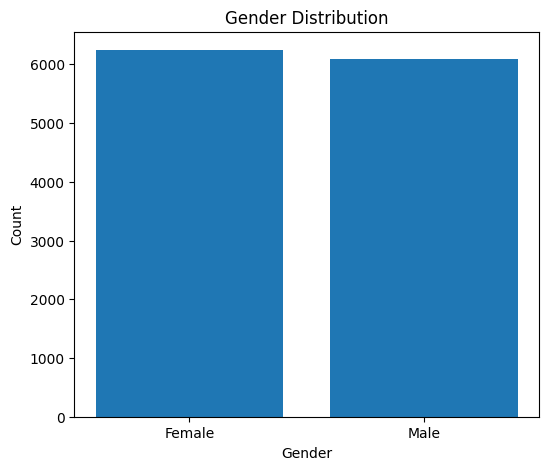

In [ ]:
gender = df['Gender'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(gender.index, gender.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.savefig("Ecommerce_Recommendation_System/screenshots/04_Gender Distribution", dpi=300, bbox_inches="tight")

plt.show()

Product Category Distribution

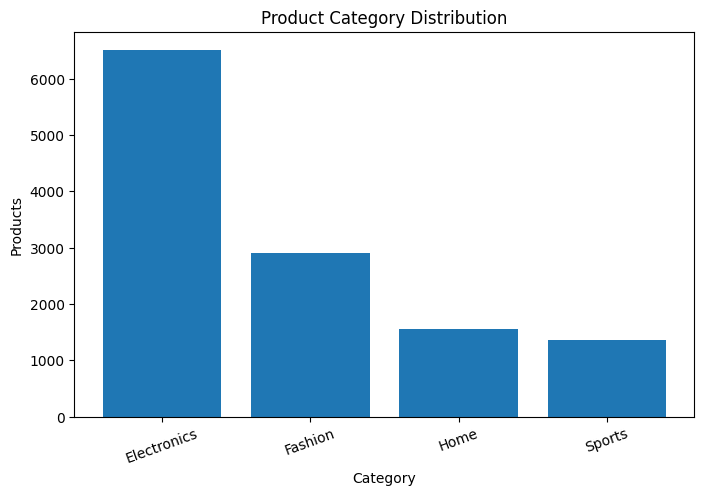

In [ ]:
category = df['Product_Category'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(category.index, category.values)
plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Products")
plt.xticks(rotation=20)
plt.savefig("Ecommerce_Recommendation_System/screenshots/05_Product Category Distribution.png", dpi=300, bbox_inches="tight")

plt.show()

Average Spending Category

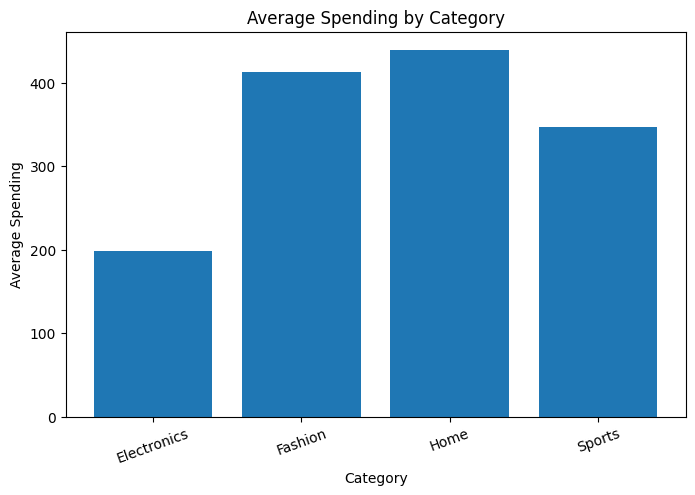

In [ ]:
avg_spending = df.groupby('Product_Category')['Total_Spending'].mean()

plt.figure(figsize=(8,5))
plt.bar(avg_spending.index, avg_spending.values)
plt.title("Average Spending by Category")
plt.xlabel("Category")
plt.ylabel("Average Spending")
plt.xticks(rotation=20)
plt.savefig("Ecommerce_Recommendation_System/screenshots/06_Average_spending.png", dpi=300, bbox_inches="tight")

plt.show()

Browsing Time Distribution

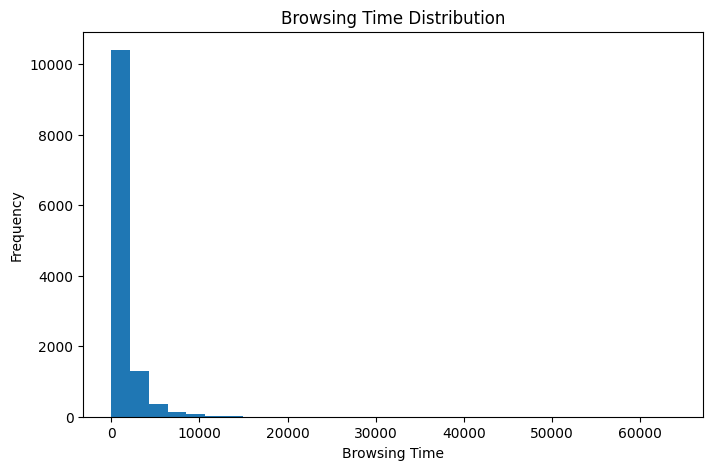

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Browsing_Time'], bins=30)
plt.title("Browsing Time Distribution")
plt.xlabel("Browsing Time")
plt.ylabel("Frequency")
plt.savefig("Ecommerce_Recommendation_System/screenshots/07_Browsing_Time.png", dpi=300, bbox_inches="tight")

plt.show()

Previous purchases

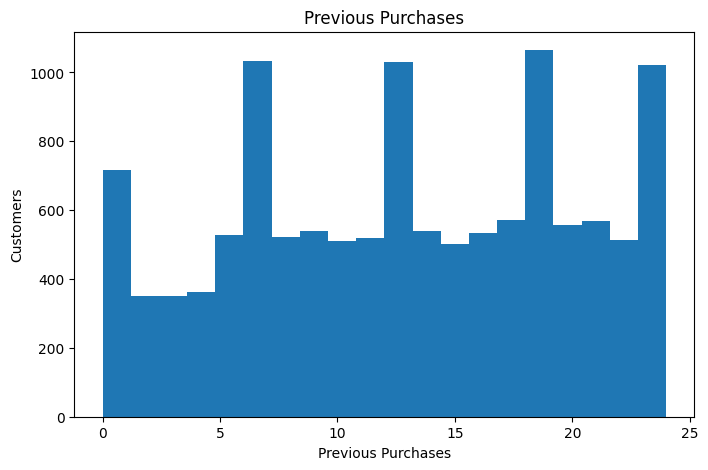

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Previous_Purchases'], bins=20)
plt.title("Previous Purchases")
plt.xlabel("Previous Purchases")
plt.ylabel("Customers")
plt.savefig("Ecommerce_Recommendation_System/screenshots/08_Previous_purchases.png", dpi=300, bbox_inches="tight")

plt.show()

Correlation Matrix

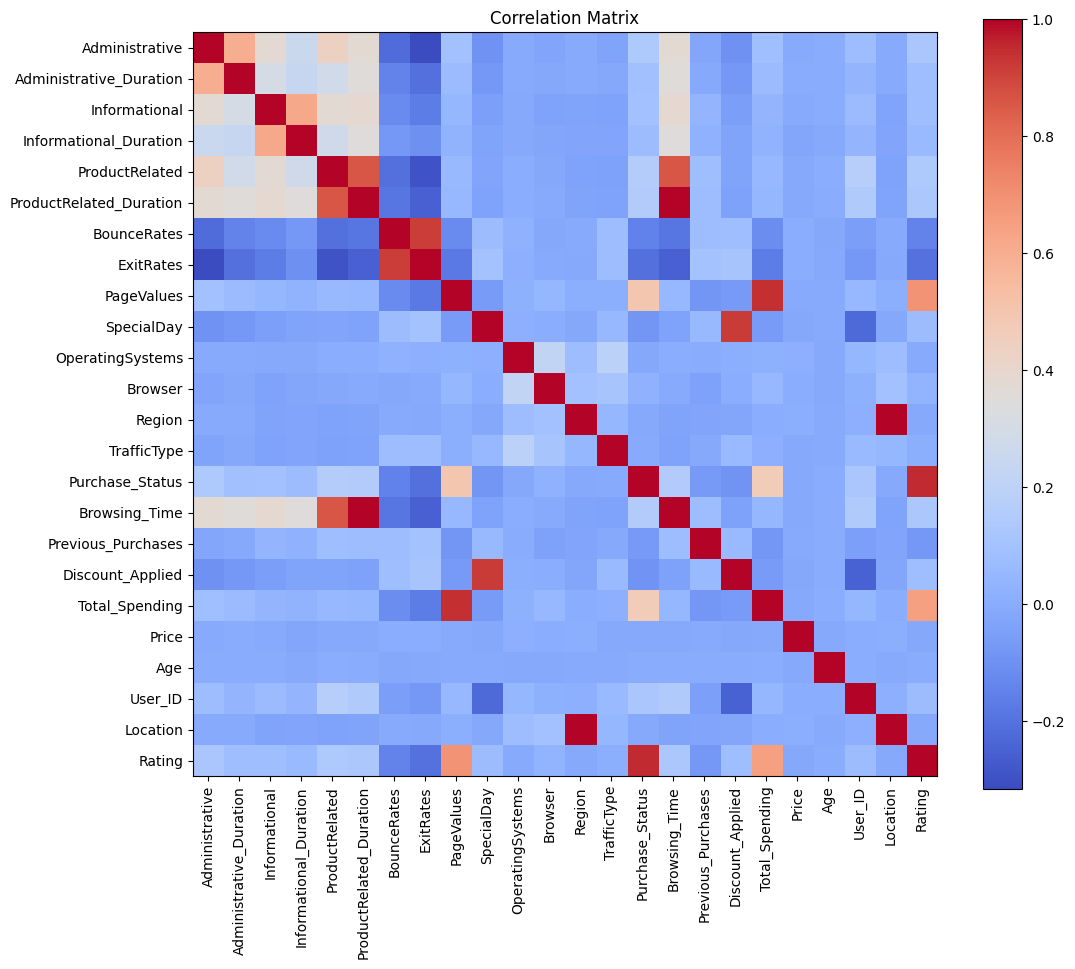

In [ ]:
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(12,10))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.savefig("Ecommerce_Recommendation_System/screenshots/09_Correlation_Matrix.png", dpi=300, bbox_inches="tight")

plt.show()

Top 10 Spending Customers

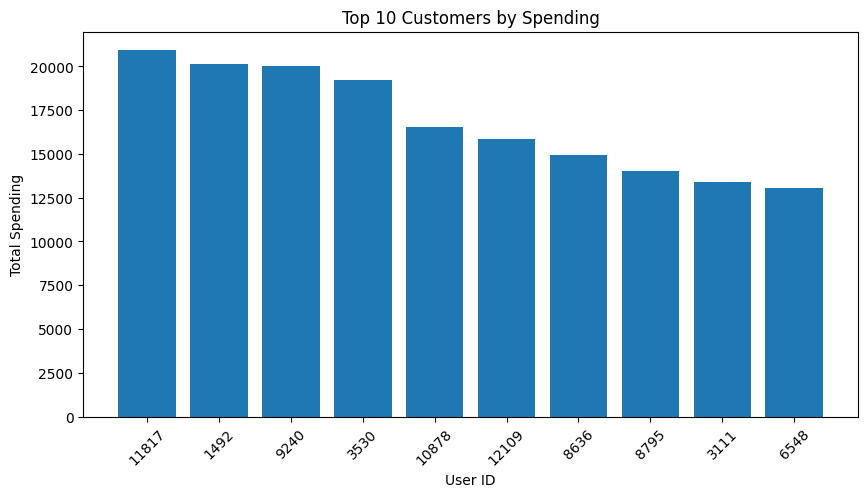

In [ ]:
top_customers = df.groupby('User_ID')['Total_Spending'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_customers.index.astype(str), top_customers.values)
plt.title("Top 10 Customers by Spending")
plt.xlabel("User ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.savefig("Ecommerce_Recommendation_System/screenshots/010_Top 10 Customers by Spending.png", dpi=300, bbox_inches="tight")

plt.show()

Purchase vs Browsing Time

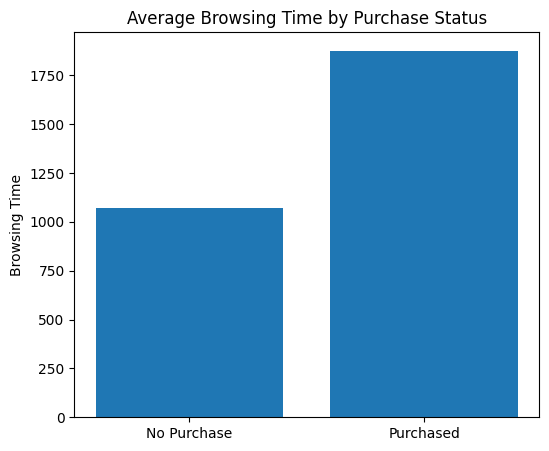

In [ ]:
purchase_mean = df.groupby('Purchase_Status')['Browsing_Time'].mean()

plt.figure(figsize=(6,5))
plt.bar(['No Purchase','Purchased'], purchase_mean.values)
plt.title("Average Browsing Time by Purchase Status")
plt.ylabel("Browsing Time")
plt.savefig("Ecommerce_Recommendation_System/screenshots/011_Average Browsing Time by Purchase Status.png", dpi=300, bbox_inches="tight")

plt.show()

Purchase Rate (%)

In [ ]:
purchase_rate = df['Purchase_Status'].mean()*100

print(f"Purchase Rate : {purchase_rate:.2f}%")

Purchase Rate : 15.47%


#**Regression – Rating Prediction**

Select Features

In [ ]:
features = [
    'Price',
    'Browsing_Time',
    'Previous_Purchases',
    'Discount_Applied',
    'Age',
    'Total_Spending'
]

X = df[features]
y = df['Rating']

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_prediction = linear_model.predict(X_test_scaled)

Evaluate Linear Regression

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

linear_mae = mean_absolute_error(y_test, linear_prediction)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_prediction
    )
)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Results
-------------------------
MAE : 0.1735243729029226
RMSE: 0.2780300574643932
R2 Score: 0.40613425121431


Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_prediction = ridge_model.predict(
    X_test_scaled
)

Evaluate Ridge Regression

In [ ]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_prediction
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_prediction
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_prediction
)

print("Ridge Regression Results")
print("-------------------------")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Ridge Regression Results
-------------------------
MAE : 0.17353016962542755
RMSE: 0.27802735675852086
R2 Score: 0.4061457884483778


Compare Both Models

In [ ]:
comparison = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Ridge Regression'
    ],

    'MAE':[
        linear_mae,
        ridge_mae
    ],

    'RMSE':[
        linear_rmse,
        ridge_rmse
    ],

    'R2 Score':[
        linear_r2,
        ridge_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.173524,0.278030,0.406134
1,Ridge Regression,0.173530,0.278027,0.406146


Actual vs Predicted Plot

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

features = [
    "Price",
    "Browsing_Time",
    "Previous_Purchases",
    "Discount_Applied",
    "Age",
    "Total_Spending"
]

X = df[features]
y = df["Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

linear_prediction = ridge_model.predict(X_test)

print("Model Trained Successfully ✅")

Model Trained Successfully ✅


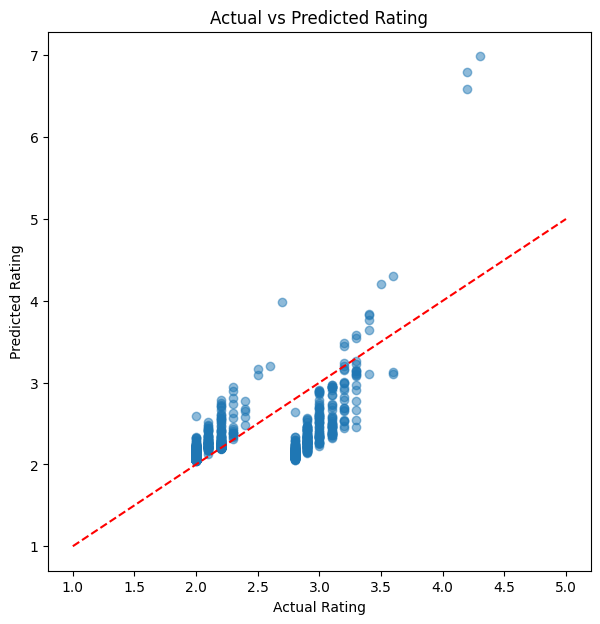

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    linear_prediction,
    alpha=0.5
)

plt.plot(
    [1,5],
    [1,5],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Rating")

plt.savefig(
    "Ecommerce_Recommendation_System/screenshots/12_Actual_Prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Feature Importance

In [ ]:
importance = pd.DataFrame({

    "Feature":features,

    "Coefficient":linear_model.coef_

})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
5,Total_Spending,0.229099
3,Discount_Applied,0.043586
1,Browsing_Time,0.034058
4,Age,-0.000467
0,Price,-0.001770
2,Previous_Purchases,-0.012093


#**Logistic Regression**

Select Features

In [ ]:
classification_features = [
    'Browsing_Time',
    'Previous_Purchases',
    'Rating',
    'Price',
    'Discount_Applied',
    'Total_Spending'
]

X = df[classification_features]
y = df['Purchase_Status']

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Train Logistic Regression

In [ ]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

Prediction

In [ ]:
y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

Evaluation Matrix

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print("ROC AUC :", roc)

Accuracy : 0.8450932684509327
Precision: 0.0
Recall : 0.0
F1 Score : 0.0
ROC AUC : 0.5002034950909949


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2084
           1       0.00      0.00      0.00       382

    accuracy                           0.85      2466
   macro avg       0.42      0.50      0.46      2466
weighted avg       0.71      0.85      0.77      2466



Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2084    0]
 [ 382    0]]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

features = [
    "Browsing_Time",
    "Previous_Purchases",
    "Price",
    "Discount_Applied",
    "Total_Spending",
    "ProductRelated",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

X = df[features]
y = df["Purchase_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1855  200]
 [ 111  300]]


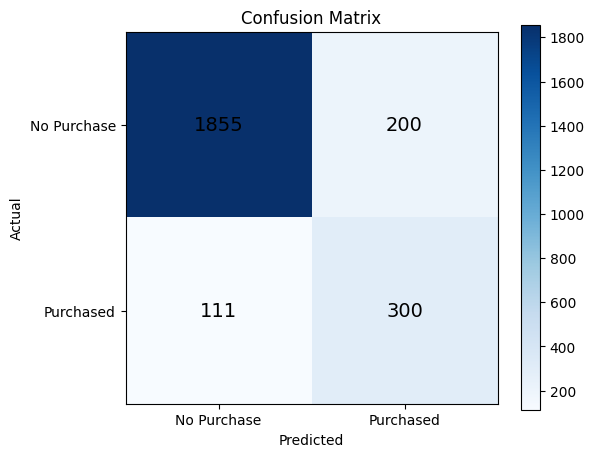

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("Ecommerce_Recommendation_System/screenshots", exist_ok=True)

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks([0,1],["No Purchase","Purchased"])
plt.yticks([0,1],["No Purchase","Purchased"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14,
            color="black"
        )

plt.savefig(
    "Ecommerce_Recommendation_System/screenshots/13_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ROC Curve

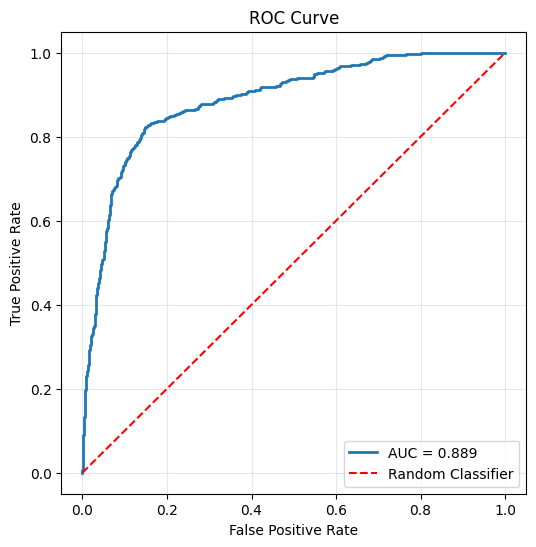

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import os

# Ensure screenshots folder exists
os.makedirs("Ecommerce_Recommendation_System/screenshots", exist_ok=True)

# Predicted probabilities
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# AUC Score
roc = roc_auc_score(y_test, y_prob)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.savefig(
    "Ecommerce_Recommendation_System/screenshots/14_ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature":classification_features,

    "Coefficient":log_model.coef_[0]

})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,Previous_Purchases,0.033343
3,Price,0.024199
2,Rating,0.009275
0,Browsing_Time,0.007839
4,Discount_Applied,0.000033
5,Total_Spending,-0.001519


#**K-Means Clustering**

Select Features for Clustering

In [ ]:
cluster_features = [
    'Browsing_Time',
    'Previous_Purchases',
    'Total_Spending',
    'Rating'
]

X_cluster = df[cluster_features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(X_cluster)

Elbow Method

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_cluster_scaled)

    inertia.append(model.inertia_)

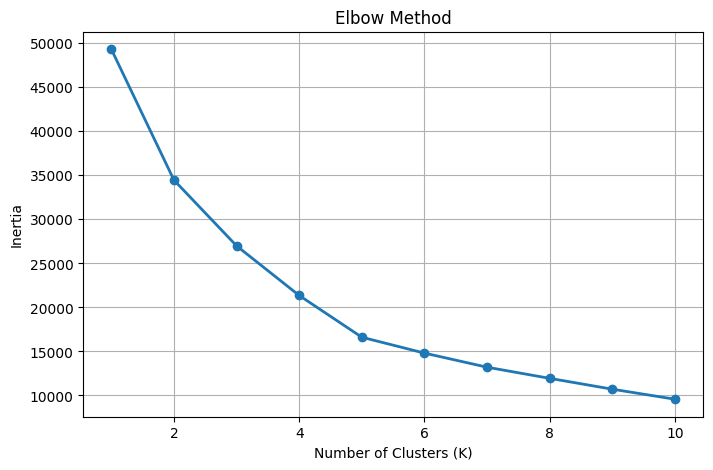

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

# Create screenshots folder
os.makedirs("Ecommerce_Recommendation_System/screenshots", exist_ok=True)

# Features for clustering
cluster_features = [
    "Browsing_Time",
    "Previous_Purchases",
    "Total_Spending",
    "Rating"
]

X = df[cluster_features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate inertia values
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)

plt.savefig(
    "Ecommerce_Recommendation_System/screenshots/15_Elbow_Method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    X_cluster_scaled
)

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,5257
1,4728
2,1788
3,557


Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_cluster_scaled,
    df['Cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.4124931761792292


In [ ]:
centers = pd.DataFrame(

    scaler.inverse_transform(
        kmeans.cluster_centers_
    ),

    columns=cluster_features

)

centers

,Browsing_Time,Previous_Purchases,Total_Spending,Rating
0,874.870870,18.587609,66.053713,2.040061
1,752.707607,6.690209,51.064975,2.026390
2,1349.811679,10.969748,1650.419179,2.942353
3,7506.646666,14.458484,194.871401,2.271119


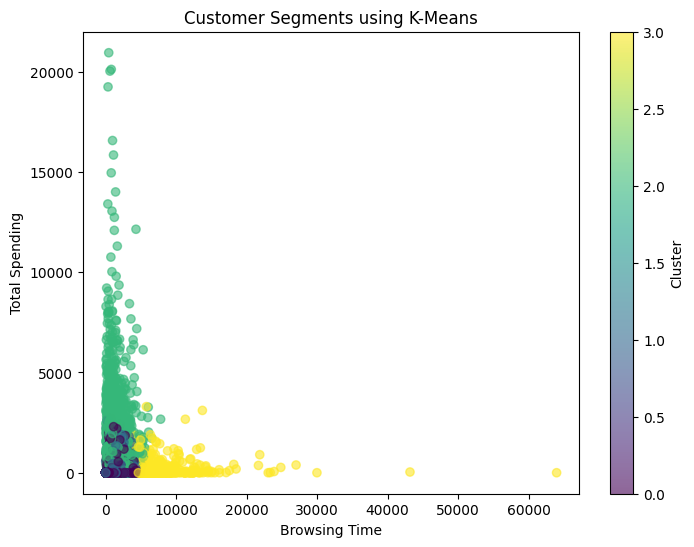

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

# Create screenshots folder
os.makedirs("Ecommerce_Recommendation_System/screenshots", exist_ok=True)

# Features for clustering
cluster_features = [
    "Browsing_Time",
    "Previous_Purchases",
    "Total_Spending",
    "Rating"
]

X = df[cluster_features]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Create Cluster column
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Plot Customer Segments
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df["Browsing_Time"],
    df["Total_Spending"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Browsing Time")
plt.ylabel("Total Spending")
plt.title("Customer Segments using K-Means")

plt.colorbar(scatter, label="Cluster")

plt.savefig(
    "Ecommerce_Recommendation_System/screenshots/16_Customer_Segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
cluster_summary = df.groupby('Cluster')[

    cluster_features

].mean().round(2)

cluster_summary

,Browsing_Time,Previous_Purchases,Total_Spending,Rating
Cluster,,,,
0,873.69,18.59,65.58,2.04
1,751.99,6.69,51.03,2.03
2,1348.51,10.99,1649.11,2.94
3,7489.57,14.47,194.61,2.27


In [ ]:
cluster_names = {

    0:"Frequent Buyers",

    1:"Discount Sensitive",

    2:"Window Shoppers",

    3:"High Value Customers"

}

df['Customer_Segment'] = df['Cluster'].map(cluster_names)

df[['Cluster','Customer_Segment']].head()

,Cluster,Customer_Segment
0,1,Discount Sensitive
1,0,Frequent Buyers
2,0,Frequent Buyers
3,0,Frequent Buyers
4,1,Discount Sensitive


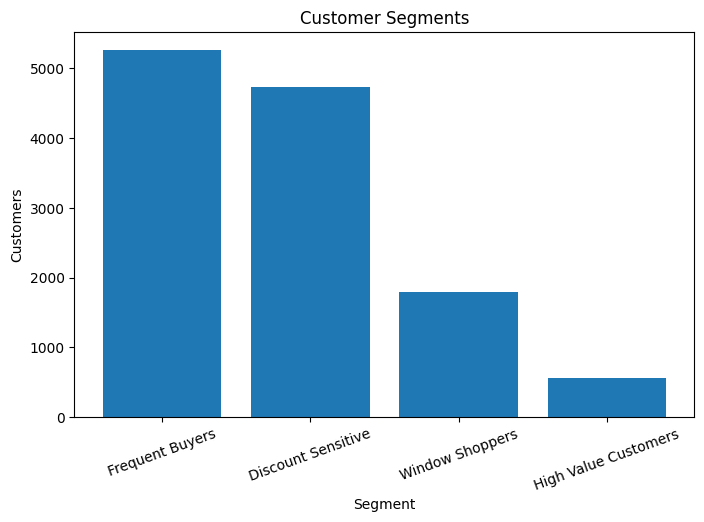

In [ ]:
import matplotlib.pyplot as plt
import os

# Create screenshots folder
os.makedirs("Ecommerce_Recommendation_System/screenshots", exist_ok=True)

# Convert Cluster numbers to names
segment_names = {
    0: "Frequent Buyers",
    1: "Discount Sensitive",
    2: "Window Shoppers",
    3: "High Value Customers"
}

df["Customer_Segment"] = df["Cluster"].map(segment_names)

# Count customers in each segment
segment_count = df["Customer_Segment"].value_counts()

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    segment_count.index,
    segment_count.values
)

plt.xticks(rotation=20)
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Customers")

# Save graph
plt.savefig(
    "Ecommerce_Recommendation_System/screenshots/17_Customer_Segment_Bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#**Hyperparameter Optimization**

Define Parameters

In [ ]:
from sklearn.model_selection import GridSearchCV

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100]
}

Apply GridSearchCV

In [ ]:
ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 50, 100]}, scoring='r2')

In [ ]:
print("Best Alpha:", ridge_grid.best_params_)
print("Best CV Score:", ridge_grid.best_score_)

Best Alpha: {'alpha': 100}
Best CV Score: -0.0014546907082008342


Best Ridge Model

In [ ]:
best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(
    X_test_scaled
)

print("MAE :", mean_absolute_error(y_test, ridge_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, ridge_pred)))

print("R2 :", r2_score(y_test, ridge_pred))

MAE : 0.26165605490179833
RMSE : 0.36187891409596273
R2 : -0.0003491878031689488


**Logistic Regression using GridSearchCV**

Parameter Grid

In [ ]:
log_params = {

    'C':[0.01,0.1,1,10],

    'solver':['liblinear','lbfgs'],

    'max_iter':[200,500,1000]

}

Apply GridSearchCV

In [ ]:
log_grid = GridSearchCV(

    LogisticRegression(),

    log_params,

    cv=5,

    scoring='accuracy'

)

log_grid.fit(

    X_train_scaled,

    y_train

)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'max_iter': [200, 500, 1000],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [ ]:
print("Best Parameters")

print(log_grid.best_params_)

print("Best Accuracy")

print(log_grid.best_score_)

Best Parameters
{'C': 0.01, 'max_iter': 200, 'solver': 'liblinear'}
Best Accuracy
0.8452960298718295


In [ ]:
best_logistic = log_grid.best_estimator_

prediction = best_logistic.predict(
    X_test_scaled
)

probability = best_logistic.predict_proba(
    X_test_scaled
)[:,1]

print("Accuracy :", accuracy_score(y_test,prediction))

print("Precision :", precision_score(y_test,prediction))

print("Recall :", recall_score(y_test,prediction))

print("F1 :", f1_score(y_test,prediction))

print("ROC AUC :", roc_auc_score(y_test,probability))

Accuracy : 0.8450932684509327
Precision : 0.0
Recall : 0.0
F1 : 0.0
ROC AUC : 0.5004597481685442


**K-Means Best Cluster Search**

Silhouette Analysis

In [ ]:
scores = []

for k in range(2,11):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    labels = model.fit_predict(
        X_cluster_scaled
    )

    score = silhouette_score(
        X_cluster_scaled,
        labels
    )

    scores.append(score)

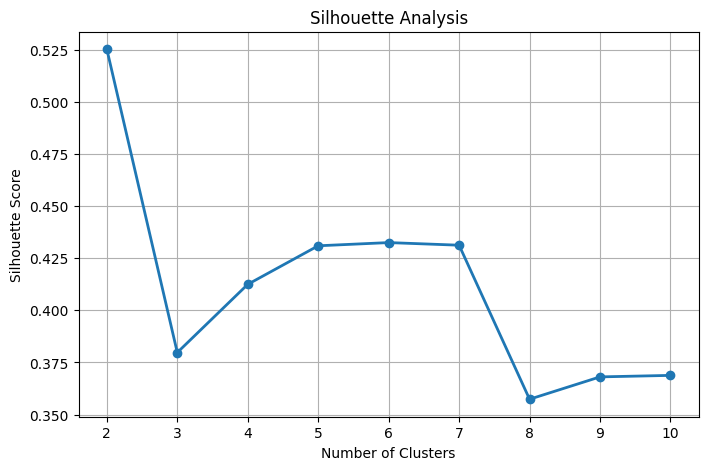

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

# Create screenshots folder
os.makedirs("Ecommerce_Recommendation_System/screenshots", exist_ok=True)

# Features for clustering
cluster_features = [
    "Browsing_Time",
    "Previous_Purchases",
    "Total_Spending",
    "Rating"
]

X = df[cluster_features]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate Silhouette Scores
scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)

plt.savefig(
    "Ecommerce_Recommendation_System/screenshots/18_Silhouette_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
best_k = scores.index(max(scores)) + 2

print("Best Number of Clusters :", best_k)

Best Number of Clusters : 2


**Model Comparison Table**

In [ ]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Ridge Regression",

        "Logistic Regression",

        "K-Means"

    ],

    "Evaluation":[

        f"MAE={linear_mae:.3f}, RMSE={linear_rmse:.3f}, R2={linear_r2:.3f}",

        f"MAE={ridge_mae:.3f}, RMSE={ridge_rmse:.3f}, R2={ridge_r2:.3f}",

        f"Accuracy={accuracy:.3f}, F1={f1:.3f}, ROC={roc:.3f}",

        f"Silhouette={score:.3f}"

    ]

})

comparison

,Model,Evaluation
0,Linear Regression,"MAE=0.174, RMSE=0.278, R2=0.406"
1,Ridge Regression,"MAE=0.174, RMSE=0.278, R2=0.406"
2,Logistic Regression,"Accuracy=0.845, F1=0.000, ROC=0.500"
3,K-Means,Silhouette=0.369


**Final Evaluation and Business Alignment**

Final Comparison Table

In [ ]:
best_silhouette = max(scores)

final_comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Logistic Regression",
        "K-Means Clustering"
    ],

    "ML Task": [
        "Rating Prediction",
        "Rating Prediction",
        "Purchase Likelihood Prediction",
        "Customer Segmentation"
    ],

    "Main Metrics": [
        f"MAE={linear_mae:.3f}, RMSE={linear_rmse:.3f}, R2={linear_r2:.3f}",
        f"MAE={ridge_mae:.3f}, RMSE={ridge_rmse:.3f}, R2={ridge_r2:.3f}",
        f"Accuracy={accuracy:.3f}, Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}, ROC-AUC={roc:.3f}",
        f"Best K={best_k}, Silhouette Score={best_silhouette:.3f}"
    ],

    "Business Value": [
        "Recommends products users may rate highly",
        "Improves rating prediction stability",
        "Identifies customers likely to purchase",
        "Groups customers for targeted marketing"
    ]

})

final_comparison

,Model,ML Task,Main Metrics,Business Value
0,Linear Regression,Rating Prediction,"MAE=0.174, RMSE=0.278, R2=0.406",Recommends products users may rate highly
1,Ridge Regression,Rating Prediction,"MAE=0.174, RMSE=0.278, R2=0.406",Improves rating prediction stability
2,Logistic Regression,Purchase Likelihood Prediction,"Accuracy=0.845, Precision=0.000, Recall=0.000,...",Identifies customers likely to purchase
3,K-Means Clustering,Customer Segmentation,"Best K=2, Silhouette Score=0.525",Groups customers for targeted marketing


Business Goal Mapping

In [ ]:
business_mapping = pd.DataFrame({

    "Business Goal": [
        "Recommend products users may like",
        "Predict whether a user will purchase",
        "Group similar customers",
        "Improve campaign targeting",
        "Increase sales conversion",
        "Improve customer experience"
    ],

    "ML Approach": [
        "Regression",
        "Classification",
        "Clustering",
        "Classification + Clustering",
        "Recommendation + Purchase Prediction",
        "Personalized Recommendations"
    ]

})

business_mapping

,Business Goal,ML Approach
0,Recommend products users may like,Regression
1,Predict whether a user will purchase,Classification
2,Group similar customers,Clustering
3,Improve campaign targeting,Classification + Clustering
4,Increase sales conversion,Recommendation + Purchase Prediction
5,Improve customer experience,Personalized Recommendations


Final Recommendation System Logic

In [ ]:
def recommendation_decision(predicted_rating, purchase_probability, customer_segment):

    if predicted_rating >= 4 and purchase_probability >= 0.7:
        return "Highly Recommended Product"

    elif predicted_rating >= 3.5 and purchase_probability >= 0.5:
        return "Recommended Product"

    elif customer_segment == "High Value Customers":
        return "Show Premium Recommendation"

    elif customer_segment == "Discount Sensitive":
        return "Show Discount Offer"

    else:
        return "Show General Recommendation"

Test Recommendation Logic

In [ ]:
recommendation_decision(
    predicted_rating=4.3,
    purchase_probability=0.78,
    customer_segment="High Value Customers"
)

'Highly Recommended Product'

**Final Business Interpretation**

The e-commerce recommendation system was developed using three machine learning approaches: regression, classification, and clustering.

Linear Regression and Ridge Regression were used to predict customer ratings. These models help identify products that a customer may rate highly. Products with higher predicted ratings can be shown in recommendation sections.

Logistic Regression was used to predict purchase likelihood. This model helps the business identify customers who are more likely to buy a product. The output can support personalized offers, targeted discounts, email campaigns, cart recovery strategies, and product ranking.

K-Means Clustering was applied to segment customers based on browsing time, previous purchases, total spending, and ratings. The model grouped customers into meaningful segments such as frequent buyers, discount-sensitive customers, window shoppers, and high-value customers.

Hyperparameter tuning was performed using GridSearchCV for Ridge Regression and Logistic Regression. Silhouette analysis was used to identify the suitable number of clusters for K-Means.

Overall, the combination of regression, classification, and clustering provides a complete recommendation framework. Regression predicts product preference, classification predicts buying intention, and clustering supports customer-level personalization.

**Final Conclusion**

This project successfully implemented and compared multiple machine learning algorithms for an e-commerce recommendation system.

The regression models helped predict product ratings, which can be used to recommend products that users are likely to prefer. Logistic Regression predicted purchase likelihood and helped identify potential buyers. K-Means Clustering grouped customers into different behavioral segments, allowing the business to create personalized marketing strategies.

The evaluation metrics showed how each model contributes to business decision-making. MAE, RMSE, and R2 Score were useful for rating prediction. Accuracy, Precision, Recall, F1-Score, and ROC-AUC were useful for purchase prediction. Inertia and Silhouette Score helped evaluate customer segmentation.

The final recommendation system can help the e-commerce company improve product recommendations, target customers more effectively, increase sales conversion, and improve customer experience.

In [ ]:
!pip install plotly -q

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.cluster import KMeans

st.set_page_config(
    page_title="CommerceAI Dashboard",
    page_icon="AI",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap');

html, body, [class*="css"] {
    font-family: 'Inter', sans-serif;
}

.stApp {
    background: #F7F8FA;
    color: #111827;
}

.block-container {
    padding-top: 1.4rem;
    max-width: 1280px;
}

[data-testid="stSidebar"] {
    background: #FFFFFF;
    border-right: 1px solid #E5E7EB;
}

[data-testid="stSidebar"] * {
    color: #111827 !important;
}

.brand-box {
    padding: 16px 4px 18px 4px;
    border-bottom: 1px solid #E5E7EB;
    margin-bottom: 14px;
}

.brand-title {
    font-size: 23px;
    font-weight: 800;
    color: #111827;
    margin-bottom: 4px;
}

.brand-subtitle {
    font-size: 13px;
    color: #6B7280;
}

.header {
    background: #FFFFFF;
    border: 1px solid #E5E7EB;
    border-radius: 18px;
    padding: 26px 30px;
    margin-bottom: 22px;
    box-shadow: 0 8px 20px rgba(15,23,42,0.04);
}

.header h1 {
    color: #111827 !important;
    font-size: 34px;
    font-weight: 800;
    margin: 0;
}

.header p {
    color: #6B7280;
    font-size: 15px;
    margin-top: 8px;
}

.card {
    background: #FFFFFF;
    border: 1px solid #E5E7EB;
    border-radius: 18px;
    padding: 24px;
    box-shadow: 0 8px 20px rgba(15,23,42,0.04);
    margin-bottom: 20px;
}

.kpi {
    background: #FFFFFF;
    border: 1px solid #E5E7EB;
    border-radius: 18px;
    padding: 22px;
    min-height: 128px;
    box-shadow: 0 8px 20px rgba(15,23,42,0.04);
}

.icon-box {
    width: 42px;
    height: 42px;
    border-radius: 12px;
    background: #EFF6FF;
    color: #2563EB;
    display: flex;
    align-items: center;
    justify-content: center;
    font-weight: 800;
    font-size: 15px;
}

.kpi-label {
    color: #6B7280;
    font-size: 13px;
    font-weight: 600;
    margin-top: 14px;
}

.kpi-value {
    color: #111827;
    font-size: 30px;
    font-weight: 800;
}

.kpi-note {
    color: #10B981;
    font-size: 12px;
    font-weight: 700;
}

.section-title {
    color: #111827;
    font-size: 24px;
    font-weight: 800;
    margin: 8px 0 18px 0;
}

.result-success {
    background: #ECFDF5;
    border: 1px solid #A7F3D0;
    color: #065F46;
    border-radius: 18px;
    padding: 28px;
    text-align: center;
    font-size: 24px;
    font-weight: 800;
    margin-top: 22px;
}

.result-danger {
    background: #FEF2F2;
    border: 1px solid #FECACA;
    color: #991B1B;
    border-radius: 18px;
    padding: 28px;
    text-align: center;
    font-size: 24px;
    font-weight: 800;
    margin-top: 22px;
}

.info-panel {
    background: #EFF6FF;
    border: 1px solid #BFDBFE;
    border-left: 5px solid #2563EB;
    border-radius: 16px;
    padding: 20px;
    color: #1E3A8A;
}

.stButton > button {
    height: 50px;
    border-radius: 12px;
    background: #111827 !important;
    color: #FFFFFF !important;
    border: 1px solid #111827 !important;
    font-weight: 700;
}

.stButton > button:hover {
    background: #2563EB !important;
    border-color: #2563EB !important;
}

label {
    color: #374151 !important;
    font-weight: 700 !important;
    font-size: 13px !important;
}

h1, h2, h3, h4 {
    color: #111827 !important;
}

.stDataFrame {
    border: 1px solid #E5E7EB;
    border-radius: 14px;
    overflow: hidden;
}
</style>
""", unsafe_allow_html=True)


def load_dataset():
    try:
        return pd.read_csv("online_shoppers_intention.csv")
    except FileNotFoundError:
        st.markdown("""
        <div class="header">
            <h1>CommerceAI Dashboard</h1>
            <p>Upload online_shoppers_intention.csv to start the live dashboard.</p>
        </div>
        """, unsafe_allow_html=True)

        uploaded_file = st.file_uploader(
            "Upload online_shoppers_intention.csv",
            type=["csv"]
        )

        if uploaded_file is not None:
            return pd.read_csv(uploaded_file)

        st.stop()


df = load_dataset()

df["Purchase_Status"] = df["Revenue"].astype(int)
df["Browsing_Time"] = df["ProductRelated_Duration"]

np.random.seed(42)

df["Previous_Purchases"] = np.where(
    df["VisitorType"] == "Returning_Visitor",
    np.random.randint(5, 25, len(df)),
    np.random.randint(0, 5, len(df))
)

df["Discount_Applied"] = np.where(df["SpecialDay"] > 0, 1, 0)
df["Total_Spending"] = df["PageValues"] * np.random.uniform(20, 80, len(df))
df["Price"] = np.random.randint(20, 1000, len(df))
df["Age"] = np.random.randint(18, 60, len(df))
df["Gender"] = np.random.choice(["Male", "Female"], size=len(df))
df["User_ID"] = np.arange(1, len(df) + 1)
df["Location"] = df["Region"]

df["Product_Category"] = np.where(
    df["ProductRelated"] < 20,
    "Electronics",
    np.where(
        df["ProductRelated"] < 40,
        "Fashion",
        np.where(df["ProductRelated"] < 70, "Home & Living", "Sports")
    )
)

df["Rating"] = (
    2
    + (df["PageValues"] / df["PageValues"].max()) * 2
    + df["Purchase_Status"] * 0.8
    + df["Discount_Applied"] * 0.2
)

df["Rating"] = df["Rating"].clip(1, 5).round(1)


st.sidebar.markdown("""
<div class="brand-box">
    <div class="brand-title">CommerceAI</div>
    <div class="brand-subtitle">ML Recommendation Dashboard</div>
</div>
""", unsafe_allow_html=True)

menu = st.sidebar.radio(
    "Navigation",
    [
        "Dashboard",
        "Rating Prediction",
        "Purchase Prediction",
        "Customer Segmentation",
        "Model Comparison"
    ]
)

st.markdown("""
<div class="header">
    <h1>E-Commerce Recommendation System</h1>
    <p>Clean machine learning dashboard for customer rating, purchase likelihood and segmentation analysis.</p>
</div>
""", unsafe_allow_html=True)


if menu == "Dashboard":

    st.markdown('<div class="section-title">Dashboard Overview</div>', unsafe_allow_html=True)

    c1, c2, c3, c4 = st.columns(4)

    with c1:
        st.markdown(f"""
        <div class="kpi">
            <div class="icon-box">US</div>
            <div class="kpi-label">Total Sessions</div>
            <div class="kpi-value">{len(df):,}</div>
            <div class="kpi-note">Active dataset</div>
        </div>
        """, unsafe_allow_html=True)

    with c2:
        st.markdown(f"""
        <div class="kpi">
            <div class="icon-box">CR</div>
            <div class="kpi-label">Purchase Rate</div>
            <div class="kpi-value">{df["Purchase_Status"].mean() * 100:.1f}%</div>
            <div class="kpi-note">Conversion rate</div>
        </div>
        """, unsafe_allow_html=True)

    with c3:
        st.markdown(f"""
        <div class="kpi">
            <div class="icon-box">RT</div>
            <div class="kpi-label">Average Rating</div>
            <div class="kpi-value">{df["Rating"].mean():.2f}</div>
            <div class="kpi-note">Predicted score</div>
        </div>
        """, unsafe_allow_html=True)

    with c4:
        st.markdown(f"""
        <div class="kpi">
            <div class="icon-box">SP</div>
            <div class="kpi-label">Average Spending</div>
            <div class="kpi-value">{df["Total_Spending"].mean():.0f}</div>
            <div class="kpi-note">Spending proxy</div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    left, right = st.columns(2)

    with left:
        st.markdown('<div class="card">', unsafe_allow_html=True)
        st.subheader("Purchase Distribution")

        purchase_df = df["Purchase_Status"].value_counts().reset_index()
        purchase_df.columns = ["Purchase Status", "Count"]
        purchase_df["Purchase Status"] = purchase_df["Purchase Status"].map({
            0: "No Purchase",
            1: "Purchased"
        })

        fig = px.bar(
            purchase_df,
            x="Purchase Status",
            y="Count",
            text="Count",
            template="plotly_white"
        )
        fig.update_layout(height=360, margin=dict(l=20, r=20, t=30, b=20), showlegend=False)
        st.plotly_chart(fig, use_container_width=True)
        st.markdown("</div>", unsafe_allow_html=True)

    with right:
        st.markdown('<div class="card">', unsafe_allow_html=True)
        st.subheader("Product Category Distribution")

        category_df = df["Product_Category"].value_counts().reset_index()
        category_df.columns = ["Category", "Count"]

        fig = px.pie(
            category_df,
            names="Category",
            values="Count",
            hole=0.55,
            template="plotly_white"
        )
        fig.update_layout(height=360, margin=dict(l=20, r=20, t=30, b=20))
        st.plotly_chart(fig, use_container_width=True)
        st.markdown("</div>", unsafe_allow_html=True)

    left2, right2 = st.columns(2)

    with left2:
        st.markdown('<div class="card">', unsafe_allow_html=True)
        st.subheader("Browsing Time Distribution")

        fig = px.histogram(
            df,
            x="Browsing_Time",
            nbins=40,
            template="plotly_white"
        )
        fig.update_layout(
            height=360,
            margin=dict(l=20, r=20, t=30, b=20),
            xaxis_title="Browsing Time",
            yaxis_title="Frequency"
        )
        st.plotly_chart(fig, use_container_width=True)
        st.markdown("</div>", unsafe_allow_html=True)

    with right2:
        st.markdown('<div class="card">', unsafe_allow_html=True)
        st.subheader("Rating Distribution")

        fig = px.histogram(
            df,
            x="Rating",
            nbins=10,
            template="plotly_white"
        )
        fig.update_layout(
            height=360,
            margin=dict(l=20, r=20, t=30, b=20),
            xaxis_title="Rating",
            yaxis_title="Frequency"
        )
        st.plotly_chart(fig, use_container_width=True)
        st.markdown("</div>", unsafe_allow_html=True)

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.subheader("Dataset Preview")
    st.dataframe(df.head(10), use_container_width=True)
    st.markdown("</div>", unsafe_allow_html=True)


elif menu == "Rating Prediction":

    st.markdown('<div class="section-title">Rating Prediction</div>', unsafe_allow_html=True)

    reg_features = [
        "Price",
        "Browsing_Time",
        "Previous_Purchases",
        "Discount_Applied",
        "Age",
        "Total_Spending"
    ]

    X = df[reg_features]
    y = df["Rating"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = Ridge(alpha=1.0)
    model.fit(X_scaled, y)

    st.markdown('<div class="card">', unsafe_allow_html=True)

    c1, c2 = st.columns(2)

    with c1:
        price = st.slider("Product Price", 20, 1000, 300)
        previous_purchases = st.slider("Previous Purchases", 0, 30, 4)
        age = st.slider("Customer Age", 18, 60, 24)

    with c2:
        browsing_time = st.slider("Browsing Time", 0.0, 10000.0, 500.0)
        discount = st.selectbox("Discount Applied", [0, 1], key="rating_discount")
        spending = st.slider("Total Spending", 0.0, 10000.0, 500.0)

    input_data = pd.DataFrame(
        [[price, browsing_time, previous_purchases, discount, age, spending]],
        columns=reg_features
    )

    input_scaled = scaler.transform(input_data)

    if st.button("Generate Rating Prediction", use_container_width=True):
        prediction = model.predict(input_scaled)[0]
        prediction = max(1, min(5, prediction))

        st.markdown(f"""
        <div class="result-success">
            Predicted Rating<br>{prediction:.2f} / 5
        </div>
        """, unsafe_allow_html=True)

    st.markdown("</div>", unsafe_allow_html=True)


elif menu == "Purchase Prediction":

    st.markdown('<div class="section-title">Purchase Likelihood Prediction</div>', unsafe_allow_html=True)

    clf_features = [
        "Browsing_Time",
        "Previous_Purchases",
        "Price",
        "Discount_Applied",
        "Total_Spending",
        "ProductRelated",
        "BounceRates",
        "ExitRates",
        "PageValues"
    ]

    X = df[clf_features]
    y = df["Purchase_Status"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X_scaled, y)

    st.markdown('<div class="card">', unsafe_allow_html=True)

    c1, c2 = st.columns(2)

    with c1:
        browsing_time = st.slider("Browsing Time", 0.0, 10000.0, 500.0)
        previous_purchases = st.slider("Previous Purchases", 0, 30, 4)
        product_related = st.slider("Product Pages Viewed", 0, 800, 20)
        price = st.slider("Product Price", 20, 1000, 300)

    with c2:
        discount = st.selectbox("Discount Applied", [0, 1], key="purchase_discount")
        page_values = st.slider("Page Values", 0.0, 400.0, 5.0)
        spending = st.slider("Total Spending", 0.0, 10000.0, 500.0)
        bounce_rates = st.slider("Bounce Rate", 0.0, 1.0, 0.02)
        exit_rates = st.slider("Exit Rate", 0.0, 1.0, 0.05)

    input_data = pd.DataFrame(
        [[
            browsing_time,
            previous_purchases,
            price,
            discount,
            spending,
            product_related,
            bounce_rates,
            exit_rates,
            page_values
        ]],
        columns=clf_features
    )

    input_scaled = scaler.transform(input_data)

    if st.button("Predict Purchase Probability", use_container_width=True):
        probability = model.predict_proba(input_scaled)[0][1] * 100
        prediction = 1 if probability >= 50 else 0

        gauge = go.Figure(go.Indicator(
            mode="gauge+number",
            value=probability,
            title={"text": "Purchase Probability"},
            gauge={
                "axis": {"range": [0, 100]},
                "bar": {"color": "#2563EB"},
                "steps": [
                    {"range": [0, 40], "color": "#FEE2E2"},
                    {"range": [40, 70], "color": "#FEF3C7"},
                    {"range": [70, 100], "color": "#DCFCE7"}
                ]
            }
        ))

        gauge.update_layout(height=300, margin=dict(l=20, r=20, t=40, b=20))
        st.plotly_chart(gauge, use_container_width=True)

        if prediction == 1:
            st.markdown(f"""
            <div class="result-success">
                Likely to Purchase<br>{probability:.2f}% Probability
            </div>
            """, unsafe_allow_html=True)
        else:
            st.markdown(f"""
            <div class="result-danger">
                Not Likely to Purchase<br>{probability:.2f}% Probability
            </div>
            """, unsafe_allow_html=True)

    st.markdown("</div>", unsafe_allow_html=True)


elif menu == "Customer Segmentation":

    st.markdown('<div class="section-title">Customer Segmentation</div>', unsafe_allow_html=True)

    cluster_features = [
        "Browsing_Time",
        "Previous_Purchases",
        "Total_Spending",
        "Rating"
    ]

    X = df[cluster_features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    st.markdown('<div class="card">', unsafe_allow_html=True)

    c1, c2 = st.columns(2)

    with c1:
        browsing_time = st.slider("Browsing Time", 0.0, 10000.0, 500.0)
        previous_purchases = st.slider("Previous Purchases", 0, 30, 4)

    with c2:
        spending = st.slider("Total Spending", 0.0, 10000.0, 500.0)
        rating = st.slider("Rating", 1.0, 5.0, 4.0)

    input_data = pd.DataFrame(
        [[browsing_time, previous_purchases, spending, rating]],
        columns=cluster_features
    )

    input_scaled = scaler.transform(input_data)

    segment_names = {
        0: "Frequent Buyer",
        1: "Discount Sensitive Customer",
        2: "Window Shopper",
        3: "High Value Customer"
    }

    if st.button("Identify Customer Segment", use_container_width=True):
        cluster = kmeans.predict(input_scaled)[0]
        segment = segment_names.get(cluster, "General Customer")

        st.markdown(f"""
        <div class="result-success">
            Customer Segment<br>{segment}
        </div>
        """, unsafe_allow_html=True)

    st.markdown("</div>", unsafe_allow_html=True)


elif menu == "Model Comparison":

    st.markdown('<div class="section-title">Model Comparison</div>', unsafe_allow_html=True)

    comparison = pd.DataFrame({
        "Model": [
            "Ridge Regression",
            "Logistic Regression",
            "K-Means Clustering"
        ],
        "Machine Learning Task": [
            "Rating Prediction",
            "Purchase Likelihood Prediction",
            "Customer Segmentation"
        ],
        "Business Value": [
            "Recommends products users may rate highly",
            "Identifies customers likely to purchase",
            "Creates customer groups for targeted marketing"
        ]
    })

    st.markdown('<div class="card">', unsafe_allow_html=True)
    st.dataframe(comparison, use_container_width=True)
    st.markdown("</div>", unsafe_allow_html=True)

    st.markdown("""
    <div class="info-panel">
        <h3>Final Business Recommendation</h3>
        <p>
        This system helps an e-commerce business improve recommendation quality,
        predict customer buying intent, and create customer segments for personalized
        marketing. Regression supports rating prediction, classification predicts
        purchase likelihood, and clustering identifies meaningful customer groups.
        </p>
    </div>
    """, unsafe_allow_html=True)

Overwriting app.py


In [ ]:
!pkill -f streamlit
!pkill -f ngrok

In [ ]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true > /content/logs.txt 2>&1 &

In [ ]:
!curl http://localhost:8501

<!--
 Copyright (c) Streamlit Inc. (2018-2022) Snowflake Inc. (2022-2026)

 Licensed under the Apache License, Version 2.0 (the "License");
 you may not use this file except in compliance with the License.
 You may obtain a copy of the License at

     http://www.apache.org/licenses/LICENSE-2.0

 Unless required by applicable law or agreed to in writing, software
 distributed under the License is distributed on an "AS IS" BASIS,
 WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
 See the License for the specific language governing permissions and
 limitations under the License.
-->

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta
      name="viewport"
      content="width=device-width, initial-scale=1, shrink-to-fit=no"
    />
    <link rel="shortcut icon" href="./favicon.png" />
    <link
      rel="preload"
      href="./static/media/SourceSansVF-Upright.ttf.BsWL4Kly.woff2"
      as="font"
      type="font/woff2"
      crossorig

In [ ]:
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3G8his1pYso9mF4JEdAL6gLJT8o_7qdeHZNXHsJ4ziRzqN8Z9")

In [ ]:
!streamlit run app.py --server.port 8501 --server.headless true &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok

ngrok.kill()
public_url = ngrok.connect(8501, "http")
print(public_url)

NgrokTunnel: "https://cauterize-coconut-renewed.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import os

folders = [
    "Ecommerce_Recommendation_System",
    "Ecommerce_Recommendation_System/notebook",
    "Ecommerce_Recommendation_System/models",
    "Ecommerce_Recommendation_System/screenshots",
    "Ecommerce_Recommendation_System/assets"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [ ]:
import shutil

shutil.copy("app.py","Ecommerce_Recommendation_System/app.py")
shutil.copy("online_shoppers_intention.csv","Ecommerce_Recommendation_System/online_shoppers_intention.csv")

'Ecommerce_Recommendation_System/online_shoppers_intention.csv'

In [ ]:
%%writefile Ecommerce_Recommendation_System/requirements.txt
streamlit
pandas
numpy
scikit-learn
matplotlib
plotly
pyngrok
joblib

Writing Ecommerce_Recommendation_System/requirements.txt


In [ ]:
%%writefile Ecommerce_Recommendation_System/README.md
# E-Commerce Recommendation System

This project predicts

- Customer Rating
- Purchase Likelihood
- Customer Segmentation

Algorithms Used

- Ridge Regression
- Logistic Regression
- KMeans Clustering

Framework

- Streamlit

Language

- Python

Dataset

- Online Shoppers Intention Dataset

Writing Ecommerce_Recommendation_System/README.md


In [ ]:
%%writefile Ecommerce_Recommendation_System/Business_Report.md
# Business Report

Objective

To build an AI based recommendation system for an E-Commerce platform.

Models Used

1. Regression
2. Classification
3. Clustering

Outcome

The system predicts customer ratings, purchase probability and customer segments to improve business decisions.

Writing Ecommerce_Recommendation_System/Business_Report.md


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("online_shoppers_intention.csv")

In [ ]:
df["Purchase_Status"] = df["Revenue"].astype(int)
df["Browsing_Time"] = df["ProductRelated_Duration"]

np.random.seed(42)

df["Previous_Purchases"] = np.where(
    df["VisitorType"] == "Returning_Visitor",
    np.random.randint(5,25,len(df)),
    np.random.randint(0,5,len(df))
)

df["Discount_Applied"] = np.where(df["SpecialDay"]>0,1,0)

df["Total_Spending"] = df["PageValues"] * np.random.uniform(20,80,len(df))

df["Price"] = np.random.randint(20,1000,len(df))

df["Age"] = np.random.randint(18,60,len(df))

df["Rating"] = (
    2
    +(df["PageValues"]/df["PageValues"].max())*2
    +df["Purchase_Status"]*0.8
    +df["Discount_Applied"]*0.2
)

df["Rating"]=df["Rating"].clip(1,5)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import joblib

reg_features = [
    "Price",
    "Browsing_Time",
    "Previous_Purchases",
    "Discount_Applied",
    "Age",
    "Total_Spending"
]

X = df[reg_features]
y = df["Rating"]

rating_scaler = StandardScaler()

X_scaled = rating_scaler.fit_transform(X)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_scaled,y)

Ridge()

In [ ]:
import os

os.makedirs(
    "Ecommerce_Recommendation_System/models",
    exist_ok=True
)

joblib.dump(
    ridge_model,
    "Ecommerce_Recommendation_System/models/rating_model.pkl"
)

joblib.dump(
    rating_scaler,
    "Ecommerce_Recommendation_System/models/rating_scaler.pkl"
)

['Ecommerce_Recommendation_System/models/rating_scaler.pkl']

In [ ]:
from sklearn.linear_model import LogisticRegression

clf_features = [
    "Browsing_Time",
    "Previous_Purchases",
    "Price",
    "Discount_Applied",
    "Total_Spending",
    "ProductRelated",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

X = df[clf_features]
y = df["Purchase_Status"]

purchase_scaler = StandardScaler()
X_scaled = purchase_scaler.fit_transform(X)

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logistic_model.fit(X_scaled, y)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
joblib.dump(
logistic_model,
"Ecommerce_Recommendation_System/models/purchase_model.pkl")

joblib.dump(
purchase_scaler,
"Ecommerce_Recommendation_System/models/purchase_scaler.pkl")

['Ecommerce_Recommendation_System/models/purchase_scaler.pkl']

In [ ]:
from sklearn.cluster import KMeans

cluster_features = [
    "Browsing_Time",
    "Previous_Purchases",
    "Total_Spending",
    "Rating"
]

X = df[cluster_features]

cluster_scaler = StandardScaler()

X_scaled = cluster_scaler.fit_transform(X)

kmeans_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_model.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [ ]:
joblib.dump(
kmeans_model,
"Ecommerce_Recommendation_System/models/clustering_model.pkl")

joblib.dump(
cluster_scaler,
"Ecommerce_Recommendation_System/models/clustering_scaler.pkl")

['Ecommerce_Recommendation_System/models/clustering_scaler.pkl']

In [ ]:
import os

os.listdir("Ecommerce_Recommendation_System/models")

['purchase_model.pkl',
 'rating_model.pkl',
 'purchase_scaler.pkl',
 'rating_scaler.pkl',
 'clustering_model.pkl',
 'clustering_scaler.pkl']

In [ ]:
!ls -R Ecommerce_Recommendation_System

Ecommerce_Recommendation_System:
app.py		    models			   README.md
assets		    notebook			   requirements.txt
Business_Report.md  online_shoppers_intention.csv  screenshots

Ecommerce_Recommendation_System/assets:

Ecommerce_Recommendation_System/models:
clustering_model.pkl   purchase_model.pkl   rating_model.pkl
clustering_scaler.pkl  purchase_scaler.pkl  rating_scaler.pkl

Ecommerce_Recommendation_System/notebook:

Ecommerce_Recommendation_System/screenshots:
'010_Top 10 Customers by Spending.png'
'011_Average Browsing Time by Purchase Status.png'
 01_purchase_distribution.png
 02_rating_distribution.png
'03_Customer Age Distribution.png'
'04_Gender Distribution.png'
'05_Product Category Distribution.png'
 06_Average_spending.png
 07_Browsing_Time.png
 08_Previous_purchases.png
 09_Correlation_Matrix.png
 12_Actual_Prediction.png
 13_Confusion_Matrix.png
 14_ROC_Curve.png
 15_Elbow_Method.png
 16_Customer_Segments.png
 17_Customer_Segment_Bar.png
 18_Silhouette_Analysis.png


In [ ]:
!zip -r Ecommerce_Recommendation_System.zip Ecommerce_Recommendation_System

updating: Ecommerce_Recommendation_System/ (stored 0%)
updating: Ecommerce_Recommendation_System/models/ (stored 0%)
updating: Ecommerce_Recommendation_System/models/purchase_model.pkl (deflated 33%)
updating: Ecommerce_Recommendation_System/models/rating_model.pkl (deflated 20%)
updating: Ecommerce_Recommendation_System/models/purchase_scaler.pkl (deflated 30%)
updating: Ecommerce_Recommendation_System/models/rating_scaler.pkl (deflated 34%)
updating: Ecommerce_Recommendation_System/models/clustering_model.pkl (deflated 88%)
updating: Ecommerce_Recommendation_System/models/clustering_scaler.pkl (deflated 37%)
updating: Ecommerce_Recommendation_System/requirements.txt (deflated 12%)
updating: Ecommerce_Recommendation_System/assets/ (stored 0%)
updating: Ecommerce_Recommendation_System/app.py (deflated 75%)
updating: Ecommerce_Recommendation_System/screenshots/ (stored 0%)
updating: Ecommerce_Recommendation_System/Business_Report.md (deflated 30%)
updating: Ecommerce_Recommendation_Syst

In [ ]:
from google.colab import files

files.download("Ecommerce_Recommendation_System.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>